### Config

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import models, transforms
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Task 1

## Part A

### Creating tensors

In [2]:
zero_tensor = torch.zeros((3), device=device)
one_tensor = torch.ones((3), device=device)  
normal_tensor = torch.randn((3, 4), device=device)
uniform_tensor = torch.rand((3, 4), device=device)

print("Zero Tensor:\n", zero_tensor)
print("\nOne Tensor:\n", one_tensor)
print("\nNormal Tensor:\n", normal_tensor)
print("\nUniform Tensor:\n", uniform_tensor)

Zero Tensor:
 tensor([0., 0., 0.], device='cuda:0')

One Tensor:
 tensor([1., 1., 1.], device='cuda:0')

Normal Tensor:
 tensor([[ 0.1940,  2.1614, -0.1721,  0.8491],
        [-1.9244,  0.6530, -0.6494, -0.8175],
        [ 0.5280, -1.2753, -1.6621, -0.3033]], device='cuda:0')

Uniform Tensor:
 tensor([[0.9877, 0.1289, 0.5621, 0.5221],
        [0.7445, 0.5955, 0.9647, 0.8979],
        [0.7730, 0.6681, 0.5462, 0.5071]], device='cuda:0')


### Operations on tensors

#### Elementwise multiplication

In [3]:
elementwise_mul = normal_tensor * uniform_tensor
print("Elementwise multiplication (normal_tensor * uniform_tensor):\n", elementwise_mul)

Elementwise multiplication (normal_tensor * uniform_tensor):
 tensor([[ 0.1916,  0.2786, -0.0967,  0.4433],
        [-1.4327,  0.3888, -0.6265, -0.7341],
        [ 0.4081, -0.8521, -0.9079, -0.1538]], device='cuda:0')


#### Matrix multiplication

In [4]:
matrix_mul = normal_tensor @ uniform_tensor.T  # (3x4) @ (4x3) -> (3x3)
print("\nMatrix multiplication (normal_tensor @ uniform_tensor.T):\n", matrix_mul)


Matrix multiplication (normal_tensor @ uniform_tensor.T):
 tensor([[ 0.8168,  2.0279,  1.9306],
        [-2.6085, -2.4044, -1.8205],
        [-0.7356, -2.2422, -1.5057]], device='cuda:0')


#### Broadcasting

In [5]:
bias = torch.tensor([1.0, 2.0, 3.0, 4.0], device=device)  # shape: (4,)
broadcasted = uniform_tensor + bias  # broadcast to (3,4)
print("\nBroadcasting (uniform_tensor + [1,2,3,4]):\n", broadcasted)


Broadcasting (uniform_tensor + [1,2,3,4]):
 tensor([[1.9877, 2.1289, 3.5621, 4.5221],
        [1.7445, 2.5955, 3.9647, 4.8979],
        [1.7730, 2.6681, 3.5462, 4.5071]], device='cuda:0')


#### Reshaping

In [6]:
print("\nOriginal shape of normal_tensor:\n", normal_tensor)
reshaped = normal_tensor.reshape(4, 3)
print("\nReshaped normal_tensor to (4,3):\n", reshaped)


Original shape of normal_tensor:
 tensor([[ 0.1940,  2.1614, -0.1721,  0.8491],
        [-1.9244,  0.6530, -0.6494, -0.8175],
        [ 0.5280, -1.2753, -1.6621, -0.3033]], device='cuda:0')

Reshaped normal_tensor to (4,3):
 tensor([[ 0.1940,  2.1614, -0.1721],
        [ 0.8491, -1.9244,  0.6530],
        [-0.6494, -0.8175,  0.5280],
        [-1.2753, -1.6621, -0.3033]], device='cuda:0')


#### Transpose

In [7]:
print("\nOriginal normal_tensor (shape 3x4):\n", normal_tensor)
transposed = normal_tensor.T
print("\nTranspose of normal_tensor (shape 4x3):\n", transposed)


Original normal_tensor (shape 3x4):
 tensor([[ 0.1940,  2.1614, -0.1721,  0.8491],
        [-1.9244,  0.6530, -0.6494, -0.8175],
        [ 0.5280, -1.2753, -1.6621, -0.3033]], device='cuda:0')

Transpose of normal_tensor (shape 4x3):
 tensor([[ 0.1940, -1.9244,  0.5280],
        [ 2.1614,  0.6530, -1.2753],
        [-0.1721, -0.6494, -1.6621],
        [ 0.8491, -0.8175, -0.3033]], device='cuda:0')


#### Concatenation

In [8]:
concat_dim0 = torch.cat([normal_tensor, uniform_tensor], dim=0)  # (6,4)
concat_dim1 = torch.cat([normal_tensor, uniform_tensor], dim=1)  # (3,8)
print("\nConcatenation along dim=0 (shape {}):\n".format(concat_dim0.shape), concat_dim0)
print("\nConcatenation along dim=1 (shape {}):\n".format(concat_dim1.shape), concat_dim1)


Concatenation along dim=0 (shape torch.Size([6, 4])):
 tensor([[ 0.1940,  2.1614, -0.1721,  0.8491],
        [-1.9244,  0.6530, -0.6494, -0.8175],
        [ 0.5280, -1.2753, -1.6621, -0.3033],
        [ 0.9877,  0.1289,  0.5621,  0.5221],
        [ 0.7445,  0.5955,  0.9647,  0.8979],
        [ 0.7730,  0.6681,  0.5462,  0.5071]], device='cuda:0')

Concatenation along dim=1 (shape torch.Size([3, 8])):
 tensor([[ 0.1940,  2.1614, -0.1721,  0.8491,  0.9877,  0.1289,  0.5621,  0.5221],
        [-1.9244,  0.6530, -0.6494, -0.8175,  0.7445,  0.5955,  0.9647,  0.8979],
        [ 0.5280, -1.2753, -1.6621, -0.3033,  0.7730,  0.6681,  0.5462,  0.5071]],
       device='cuda:0')


### Mistakes to avoid

- **Elementwise add:** $(3,4) + (3,5)$ fails because dimensions are neither equal nor broadcastable.
- **Matrix multiply:** $(3,4) @ (3,5)$ fails because inner dimensions $4$ and $3$ do not match.
- **Concatenation:** `dim=0` requires other dims to match; $(2,3)$ and $(2,4)$ mismatch at dim=1.
- **Reshape/view:** $(2,3,4)$ has 24 elements, so `view(5,5)` (25 elements) fails.
- **Broadcasting:** $(2,1,3) + (3,2)$ fails after alignment because the last dims are $3$ and $2$.

In [9]:
def show_error(label, fn):
    print(f"\n{label}")
    try:
        fn()
    except Exception as exc:
        print("Error:", exc)

show_error("Elementwise add: (3,4) + (3,5)", lambda: torch.randn(3, 4) + torch.randn(3, 5))
show_error("Matrix multiply: (3,4) @ (3,5)", lambda: torch.randn(3, 4) @ torch.randn(3, 5))
show_error("Concatenation dim=0: (2,3) and (2,4)", lambda: torch.cat([torch.randn(2, 3), torch.randn(2, 4)], dim=0))
show_error("Reshape: (2,3,4) -> (5,5)", lambda: torch.randn(2, 3, 4).view(5, 5))
show_error("Broadcasting: (2,1,3) + (3,2)", lambda: torch.randn(2, 1, 3) + torch.randn(3, 2))


Elementwise add: (3,4) + (3,5)
Error: The size of tensor a (4) must match the size of tensor b (5) at non-singleton dimension 1

Matrix multiply: (3,4) @ (3,5)
Error: mat1 and mat2 shapes cannot be multiplied (3x4 and 3x5)

Concatenation dim=0: (2,3) and (2,4)
Error: Sizes of tensors must match except in dimension 0. Expected size 3 but got size 4 for tensor number 1 in the list.

Reshape: (2,3,4) -> (5,5)
Error: shape '[5, 5]' is invalid for input of size 24

Broadcasting: (2,1,3) + (3,2)
Error: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 2


## Part B

### Dot product
For vectors $a, b \in \mathbb{R}^n$, the dot product is
$$
a \cdot b = \sum_{i=1}^{n} a_i b_i
$$
We compute it manually with a loop and compare with `torch.dot`.

In [10]:
a = torch.randn(5, device=device)
b = torch.randn(5, device=device)

dot_manual = 0.0
for i in range(a.shape[0]):
    dot_manual += a[i] * b[i]

dot_builtin = torch.dot(a, b)

print("Dot manual:", dot_manual.item())
print("Dot built-in:", dot_builtin.item())
print("Match:", torch.allclose(dot_manual, dot_builtin))

Dot manual: -1.213310718536377
Dot built-in: -1.2133108377456665
Match: True


### Matrix-vector multiplication
We compute each output entry explicitly with nested loops: for each row of $M$, multiply with $v$, accumulate into a scalar, and store it in the result vector. Then we compare with `torch.mv`.

In [11]:
M = torch.randn(4, 6, device=device)
v = torch.randn(6, device=device)

matvec_manual = torch.zeros(M.shape[0], device=device)
for i in range(M.shape[0]):
    acc = 0.0
    for j in range(M.shape[1]):
        acc += M[i, j] * v[j]
    matvec_manual[i] = acc

matvec_builtin = torch.mv(M, v)

print("Mat-vec manual:", matvec_manual)
print("Mat-vec built-in:", matvec_builtin)
print("Match:", torch.allclose(matvec_manual, matvec_builtin))

Mat-vec manual: tensor([ 1.1641,  3.9499, -3.8819, -0.8067], device='cuda:0')
Mat-vec built-in: tensor([ 1.1641,  3.9499, -3.8819, -0.8067], device='cuda:0')
Match: True


### Batch matrix multiplication
We compute $C[b,i,j] = \sum_k A[b,i,k] \cdot B[b,k,j]$ with three nested loops over $i$, $j$, and $k$ for each batch index $b$. Then we compare with `torch.bmm`.

In [12]:
A = torch.randn(3, 2, 4, device=device)
B = torch.randn(3, 4, 5, device=device)

bmm_manual = torch.zeros(A.shape[0], A.shape[1], B.shape[2], device=device)
for b in range(A.shape[0]):
    for i in range(A.shape[1]):
        for j in range(B.shape[2]):
            acc = 0.0
            for k in range(A.shape[2]):
                acc += A[b, i, k] * B[b, k, j]
            bmm_manual[b, i, j] = acc

bmm_builtin = torch.bmm(A, B)

print("BMM manual shape:", bmm_manual.shape)
print("BMM built-in shape:", bmm_builtin.shape)
print("Match:", torch.allclose(bmm_manual, bmm_builtin))

BMM manual shape: torch.Size([3, 2, 5])
BMM built-in shape: torch.Size([3, 2, 5])
Match: True


### Explanation

#### Difference between elementwise and matrix multiplication
- **Elementwise:** multiplies matching entries, so shapes must be equal or broadcastable. For matrices $A,B \in \mathbb{R}^{n \times m}$, the result is $C_{ij} = A_{ij} B_{ij}$.
- **Matrix multiplication:** combines rows and columns, so inner dimensions must match. For $A \in \mathbb{R}^{n \times m}$ and $B \in \mathbb{R}^{m \times k}$, the result is $C \in \mathbb{R}^{n \times k}$ with $C_{ij} = \sum_{t=1}^{m} A_{it} B_{tj}$.

#### Broadcasting rules in PyTorch
- Compare shapes from the last dimension backward.
- Two dimensions are compatible if they are equal or one of them is $1$.
- Missing leading dimensions are treated as size $1$.
- The result size is the maximum along each dimension after alignment.
- If any dimension pair is incompatible, broadcasting fails.

#### Computational complexity
$ \mathbb{R}^{nmn \times mnm} \times \mathbb{R}^{mkm \times kmk} = \mathbb{R}^{nmn \times kmk} $

The complexity is $O(nmn \cdot mnm \cdot kmk) = O(n^5 \cdot m^4)$, since $mnm = mkm$, and we get $nmn \cdot kmk$ entries, each computed with $O(mnm)$ operations.

# Task 2

## Dataset

### W and b initialization

In [13]:
W = torch.rand(1, device=device)
b = torch.rand(1, device=device)
print("W:", W.item())
print("b:", b.item())

W: 0.5480090975761414
b: 0.2663445770740509


### Input data

X: tensor([32.7309, 56.4553, 23.0322, 27.7747, 25.5660, 85.4208, 69.4220,  7.7817,
        22.3728, 55.5083, 81.4082, 40.7025, 92.9292, 73.1544, 34.4493, 46.6815,
        43.9688,  4.5343, 96.0036, 79.8761, 19.1377, 92.4027, 12.6151, 30.1244,
        32.6342, 72.9686, 60.0513, 40.1324, 11.9549,  2.9788,  9.5380, 13.3278,
        22.0685,  7.8978, 18.0656, 42.6053, 38.2468, 24.2549, 10.6934, 33.6908,
        98.8103, 12.9182, 30.4724, 93.9559, 71.6721, 48.8825, 18.1313,  8.9788,
         2.9263,  0.4842, 37.7524, 25.6127, 55.1558, 57.3647, 28.1616, 63.3190,
        16.0325, 93.6988, 50.1817, 37.2029, 34.0302, 65.3934, 66.0306, 67.4285,
        15.2581, 85.9883, 19.4773, 98.9665, 31.5575, 40.6200, 99.5067, 81.9079,
        28.8916, 96.3401, 42.3811, 83.1622, 94.9519, 11.2367, 13.0404, 62.1476,
        91.2665, 58.0068, 85.3439, 59.1814,  3.5815, 22.3798, 38.0852, 33.9350,
        19.6227, 86.9197, 19.7284, 64.4115, 47.3967, 79.6194, 15.3920, 67.2369,
        31.2672, 38.4807, 18.3074, 41

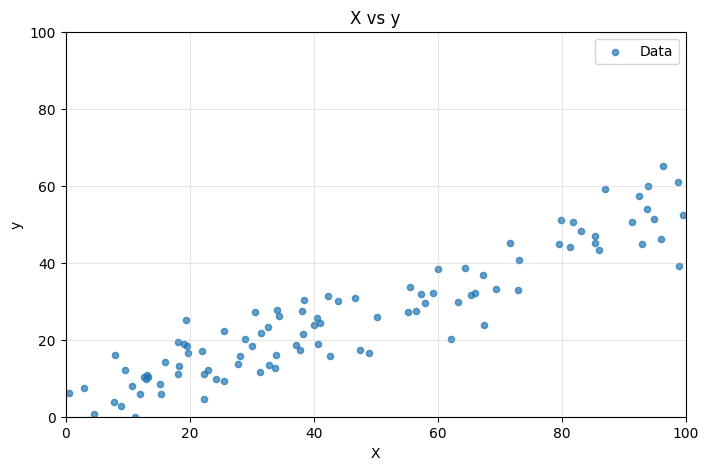

In [14]:
noise = torch.randn(100, device=device)*5
X = torch.rand(100, device=device)*100
y = W * X + b + noise
print("X:", X)
print("y:", y)

x_cpu = X.detach().cpu()
y_cpu = y.detach().cpu()

plt.figure(figsize=(8, 5))
plt.scatter(x_cpu, y_cpu, s=20, alpha=0.7, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("X vs y")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Model

### Initialization

In [15]:
model_W = torch.rand(1, device=device)
model_b = torch.rand(1, device=device)
print("Initial model W:", model_W.item())
print("Initial model b:", model_b.item())

Initial model W: 0.38064852356910706
Initial model b: 0.21966829895973206


### Predictions

Predicted y: tensor([12.6786, 21.7093,  8.9869, 10.7921,  9.9513, 32.7350, 26.6450,  3.1817,
         8.7358, 21.3488, 31.2076, 15.7130, 35.5930, 28.0658, 13.3327, 17.9889,
        16.9563,  1.9456, 36.7633, 30.6244,  7.5044, 35.3926,  5.0216, 11.6865,
        12.6418, 27.9951, 23.0781, 15.4960,  4.7703,  1.3535,  3.8503,  5.2929,
         8.6200,  3.2260,  7.0963, 16.4373, 14.7782,  9.4523,  4.2901, 13.0440,
        37.8317,  5.1370, 11.8189, 35.9838, 27.5016, 18.8267,  7.1213,  3.6374,
         1.3336,  0.4040, 14.5901,  9.9691, 21.2147, 22.0555, 10.9393, 24.3220,
         6.3224, 35.8860, 19.3213, 14.3809, 13.1732, 25.1116, 25.3541, 25.8862,
         6.0276, 32.9510,  7.6337, 37.8911, 12.2320, 15.6816, 38.0968, 31.3978,
        11.2172, 36.8914, 16.3520, 31.8752, 36.3630,  4.4969,  5.1835, 23.8761,
        34.9601, 22.2999, 32.7057, 22.7470,  1.5830,  8.7385, 14.7167, 13.1370,
         7.6890, 33.3055,  7.7293, 24.7378, 18.2611, 30.5267,  6.0786, 25.8133,
        12.1215, 14.8673,  

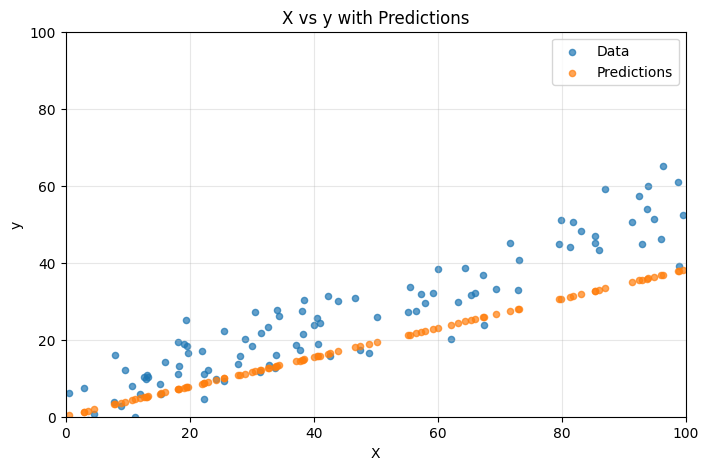

In [16]:
y_pred = model_W * X + model_b
print("Predicted y:", y_pred)

plt.figure(figsize=(8, 5))
plt.scatter(x_cpu, y_cpu, s=20, alpha=0.7, label="Data")
plt.scatter(x_cpu, y_pred.detach().cpu(), s=20, alpha=0.7, label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("X vs y with Predictions")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Mean Squared Error loss

In [17]:
mse_loss = torch.mean((y_pred - y) ** 2)
print("MSE Loss:", mse_loss.item())

MSE Loss: 118.59386444091797


## Explanation

> What does the weight represent geometrically?

The angle of the line.

> What does the bias represent?

The intercept of the line with the y-axis.

> Why does random initialization produce poor predictions?

The model parameters are initialized independently of the data, so the initial line is likely far from the optimal fit, resulting in large prediction errors.

# Task 3

## Pretrained ResNet18 (Task 3)
Steps: load model, preprocess images, run inference, and compare normalization.

In [18]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights).to(device)
model.eval()

class_names = weights.meta["categories"]
print("Classes:", len(class_names))

Classes: 1000


In [ ]:
image_dir = Path("task3_images")
image_dir.mkdir(exist_ok=True)

def list_image_paths(folder ):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    paths = [p for p in sorted(folder.iterdir()) if p.suffix.lower() in exts]
    return paths

image_paths = list_image_paths(image_dir )
pil_images = [Image.open(p).convert("RGB") for p in image_paths]

resize_size = 256
crop_size = 224

transform_normalized = weights.transforms()

transform_no_norm = transforms.Compose([
    transforms.Resize(resize_size),
    transforms.CenterCrop(crop_size),
    transforms.ToTensor()
])

In [23]:
def run_inference(images, transform, label, image_labels=None, top_k=5):
    if len(images) == 0:
        print(f"\n{label}")
        print("No images found in task3_images.")
        return

    model.eval()
    batch = torch.stack([transform(img) for img in images]).to(device)
    with torch.no_grad():
        logits = model(batch)
        probs = F.softmax(logits, dim=1)

    print(f"\n{label}")

    cols = min(3, len(images))
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, (img, ax) in enumerate(zip(images, axes)):
        ax.imshow(img)
        title = f"Image {i + 1}"
        if image_labels is not None:
            title = f"{title}: {image_labels[i]}"
        ax.set_title(title)
        ax.axis("off")

    for j in range(len(images), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    for i, prob in enumerate(probs):
        top_prob, top_idx = torch.topk(prob, k=top_k)
        header = f"Image {i + 1}"
        if image_labels is not None:
            header = f"{header}: {image_labels[i]}"
        print(header)
        for cls_idx, p in zip(top_idx.tolist(), top_prob.tolist()):
            print(f"  {class_names[cls_idx]:<25} {p:.4f}")


With ImageNet normalization


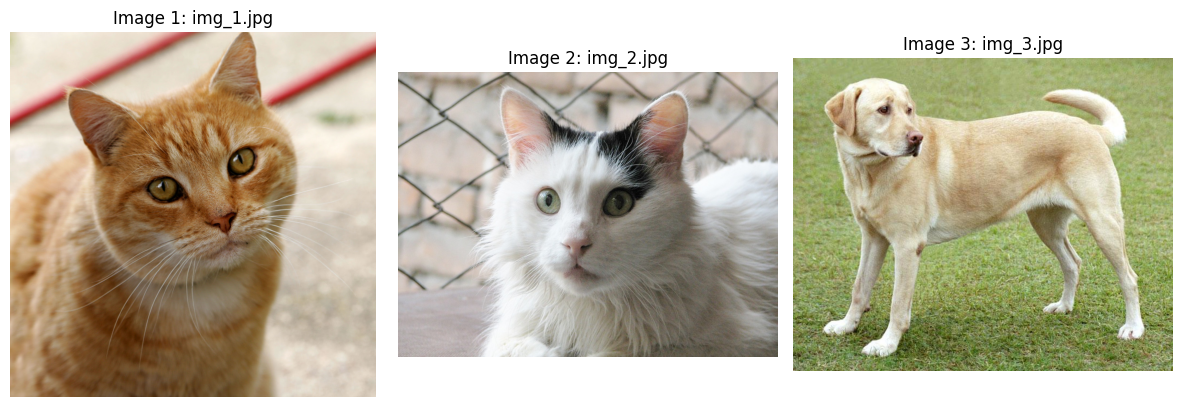

Image 1: img_1.jpg
  Egyptian cat              0.4105
  tiger cat                 0.3944
  tabby                     0.1543
  lynx                      0.0211
  mouse                     0.0023
Image 2: img_2.jpg
  Egyptian cat              0.5080
  lynx                      0.1765
  tabby                     0.0755
  tiger cat                 0.0471
  Angora                    0.0387
Image 3: img_3.jpg
  Labrador retriever        0.7066
  golden retriever          0.0499
  Saluki                    0.0448
  Chesapeake Bay retriever  0.0393
  bull mastiff              0.0260

Without normalization


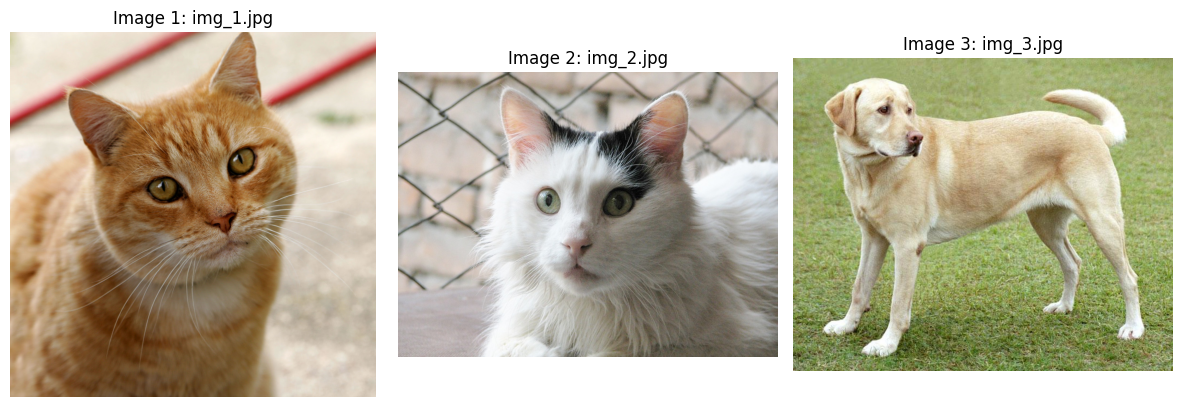

Image 1: img_1.jpg
  Egyptian cat              0.5497
  tiger cat                 0.1910
  lynx                      0.0990
  tabby                     0.0884
  carton                    0.0162
Image 2: img_2.jpg
  Persian cat               0.2927
  Egyptian cat              0.2605
  Angora                    0.1045
  lynx                      0.0689
  tabby                     0.0642
Image 3: img_3.jpg
  Saluki                    0.5519
  Labrador retriever        0.1662
  Great Dane                0.0674
  Ibizan hound              0.0294
  Weimaraner                0.0273


In [24]:
image_labels = [p.name for p in image_paths]
run_inference(pil_images, transform_normalized, "With ImageNet normalization", image_labels=image_labels)
run_inference(pil_images, transform_no_norm, "Without normalization", image_labels=image_labels)

## Explanation
- **Why call `model.eval()`?** 
  
  It switches the network to inference mode: layers like dropout are disabled and batch norm uses stored running statistics instead of batch statistics, giving deterministic, correct predictions.
- **What happens if normalization is skipped?** 
  
  The input scale and channel statistics no longer match what the model was trained on, so activations shift and predictions often degrade or become unstable.
- **What is a logit?** 
  
  Logit is a function that maps probabilities from the interval $(0,1)$ to the entire real line $(-\infty, \infty)$. In the context of neural networks, logits are the raw, unnormalized scores the model outputs before turning them into a probability distribution. They can be positive or negative and do not sum to 1.
- **Why apply softmax for probabilities?** 
  
  Softmax converts logits into non-negative values that sum to $1$, which can be interpreted as class probabilities.